# 12. Round trip to ring: interactive all-pass ring

Sliders for the four knobs of the ring plant: the field retention per lap **a**, the coupler through-amplitude **t**,
the group index **n_g** (sets the FSR), and the ring **temperature** (moves the notch at 50 pm/K under a fixed laser).

The through-port transmission is (docs/NOTES.md section 28 for *a*; e^{jωt} convention):

$$T(\lambda)=\left|\frac{t-a\,e^{-j\varphi}}{1-t\,a\,e^{-j\varphi}}\right|^2,\qquad \varphi=\beta L=\frac{2\pi\, n(\lambda)\,L}{\lambda},\qquad n(\lambda)=n_{eff}-(\lambda-\lambda_0)\frac{n_g-n_{eff}}{\lambda_0}$$

Run every cell (Kernel → Restart & Run All). The sliders need a live kernel; the saved outputs show the default state.

In [1]:
import sys, pathlib, json
ROOT = pathlib.Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT))
from common import REF, use_style, SERIES, PALETTE, C0
from common.units import db_per_cm_to_alpha_per_um
use_style()
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Checkbox
OUT = pathlib.Path.cwd() / "out"

LAM0 = REF.lambda_nm            # nm
L = REF.round_trip_um           # um
M = int(round(REF.neff * L / (LAM0 * 1e-3)))
NEFF = M * (LAM0 * 1e-3) / L    # nudged so a resonance sits exactly at 1310.000 nm (see README)

def retention(loss_db_cm, L_um=L):
    alpha = db_per_cm_to_alpha_per_um(loss_db_cm)
    return np.exp(-alpha * L_um / 2)

def ring_T(wl_nm, t, a, ng=REF.ng, neff=NEFF, L_um=L):
    wl = wl_nm * 1e-3
    n = neff - (wl - LAM0 * 1e-3) * (ng - neff) / (LAM0 * 1e-3)
    phi = 2 * np.pi * n * L_um / wl
    s = (t - a * np.exp(-1j * phi)) / (1 - t * a * np.exp(-1j * phi))
    return np.abs(s) ** 2, np.unwrap(np.angle(s))

def numbers(t, a, ng=REF.ng, L_um=L, lam_nm=LAM0):
    fsr_nm = lam_nm ** 2 / (ng * L_um * 1e3)
    fwhm_pm = (1 - t * a) * lam_nm ** 2 / (np.pi * ng * L_um * 1e3 * np.sqrt(t * a)) * 1e3
    return dict(fsr_nm=fsr_nm, fsr_thz=C0 / (ng * L_um * 1e-6) / 1e12, fwhm_pm=fwhm_pm, q=lam_nm * 1e3 / fwhm_pm,
                t_min=((t - a) / (1 - t * a)) ** 2, build_up=(1 - t ** 2) / (1 - t * a) ** 2)

print(f"a (doped, 125 dB/cm) = {retention(REF.loss_db_cm_doped):.4f}   a (passive, 3 dB/cm) = {retention(REF.loss_db_cm_passive):.5f}")
print("reference ring:", {k: round(v, 3) for k, v in numbers(REF.t_coupler, retention(REF.loss_db_cm_doped)).items()})

a (doped, 125 dB/cm) = 0.9446   a (passive, 3 dB/cm) = 0.99863
reference ring: {'fsr_nm': 10.318, 'fsr_thz': 1.803, 'fwhm_pm': np.float64(373.166), 'q': np.float64(3510.506), 't_min': np.float64(0.0), 'build_up': np.float64(9.283)}


## 1. The SAX circuit is the same thing as the closed form
A coupler (2×2 S-matrix with the −j cross term, notes 27) and one lossy dispersive waveguide closed on itself.

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


max |T_sax - T_closed_form| = 6.530941369387033e-05


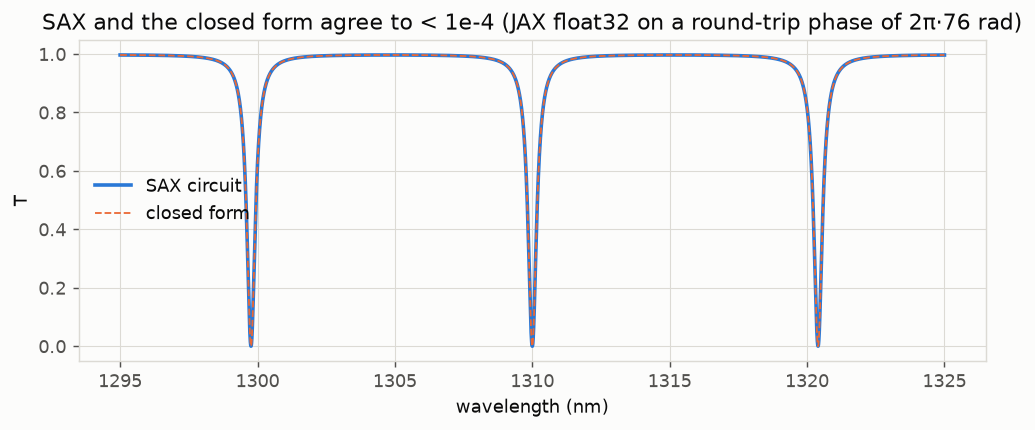

In [2]:
import sax, jax.numpy as jnp
def coupler(coupling=REF.kappa2):
    k = coupling ** 0.5; tt = (1 - coupling) ** 0.5
    return sax.reciprocal({("in0","out0"): tt, ("in0","out1"): -1j*k, ("in1","out0"): -1j*k, ("in1","out1"): tt})
def waveguide(wl=1.31, length=L, neff=NEFF, ng=REF.ng, wl0=LAM0*1e-3, loss_db_cm=REF.loss_db_cm_doped):
    n = neff - (wl - wl0) * (ng - neff) / wl0
    amp = 10 ** (-loss_db_cm * length * 1e-4 / 20)
    return sax.reciprocal({("in0","out0"): amp * jnp.exp(-2j*jnp.pi*n*length/wl)})
ring, _ = sax.circuit(netlist={"instances": {"c": "coupler", "r": "waveguide"},
                               "connections": {"c,out1": "r,in0", "r,out0": "c,in1"},
                               "ports": {"in": "c,in0", "out": "c,out0"}},
                      models={"coupler": coupler, "waveguide": waveguide})
wl = np.linspace(1295, 1325, 30001)
S = ring(wl=jnp.asarray(wl * 1e-3))
T_sax = np.abs(np.asarray(S["in", "out"])) ** 2
T_an, _ = ring_T(wl, REF.t_coupler, retention(REF.loss_db_cm_doped))
print("max |T_sax - T_closed_form| =", np.max(np.abs(T_sax - T_an)))
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(wl, T_sax, label="SAX circuit"); ax.plot(wl, T_an, "--", lw=1, label="closed form")
ax.set(xlabel="wavelength (nm)", ylabel="T", title="SAX and the closed form agree to < 1e-4 (JAX float32 on a round-trip phase of 2π·76 rad)"); ax.legend(); plt.show()

## 2. Sliders: a, t, n_g and temperature
The laser is fixed at λ_L = 1310.000 + 0.108 nm (the max-OMA bias δ_opt = +108 pm at 25 °C).
Move **temperature** and watch the notch slide under it at 50 pm/K; move **t** across **a** to go from under- to over-coupled.

In [3]:
LAM_L = LAM0 + REF.delta_opt_pm * 1e-3
DLDT = REF.dlambda_dT_pm_per_K * 1e-3     # nm/K
def show(a=0.945, t=0.945, ng=4.2, temp_C=25.0, show_phase=False):
    nums = numbers(t, a, ng)
    fsr = nums["fsr_nm"]
    shift = (temp_C - 25.0) * DLDT
    wl = np.linspace(LAM0 - 1.2 * fsr, LAM0 + 1.2 * fsr, 6001)
    T, ph = ring_T(wl - shift, t, a, ng)
    T_L, _ = ring_T(np.array([LAM_L - shift]), t, a, ng)
    fig, ax = plt.subplots(1, 2 if show_phase else 1, figsize=(12 if show_phase else 8, 3.6), squeeze=False)
    A = ax[0, 0]
    A.plot(wl, T, color=SERIES[0], label=f"ring at {temp_C:.1f} °C (resonance shift {shift*1e3:+.0f} pm)")
    A.axvline(LAM_L, color=SERIES[1], lw=2, label=f"laser {LAM_L:.3f} nm: T = {T_L[0]:.3f}")
    A.plot(LAM_L, T_L[0], "o", color=SERIES[1], ms=8)
    regime = "critical" if abs(t - a) < 1e-3 else ("under-coupled (t > a)" if t > a else "over-coupled (t < a)")
    A.set(xlabel="wavelength (nm)", ylabel="through transmission T", ylim=(-0.03, 1.05),
          title=f"{regime}: FSR {fsr:.2f} nm, FWHM {nums['fwhm_pm']:.0f} pm, Q {nums['q']:.0f}, T_min {nums['t_min']:.3f}, build-up {nums['build_up']:.1f}x")
    A.legend(loc="lower left", fontsize=8.5)
    if show_phase:
        B = ax[0, 1]; B.plot(wl, np.degrees(ph - ph[0]), color=SERIES[0])
        B.set(xlabel="wavelength (nm)", ylabel="through phase (deg)", title="phase (over-coupled wraps 360° per resonance)")
    plt.show()
interact(show, a=FloatSlider(min=0.80, max=1.00, step=0.001, value=0.945, readout_format=".3f"),
               t=FloatSlider(min=0.80, max=1.00, step=0.001, value=0.945, readout_format=".3f"),
               ng=FloatSlider(min=3.0, max=5.0, step=0.05, value=4.2),
               temp_C=FloatSlider(min=-20, max=260, step=0.5, value=25.0),
               show_phase=Checkbox(value=False));

interactive(children=(FloatSlider(value=0.945, description='a', max=1.0, min=0.8, readout_format='.3f', step=0…

## 3. Sweeps you can read off without sliders
Left: notch depth versus coupler amplitude for the doped ring (the fabrication lottery: only t = a nulls the through port).
Right: how the fixed laser sees the ring as the ambient goes 10 → 125 °C, for three couplers.

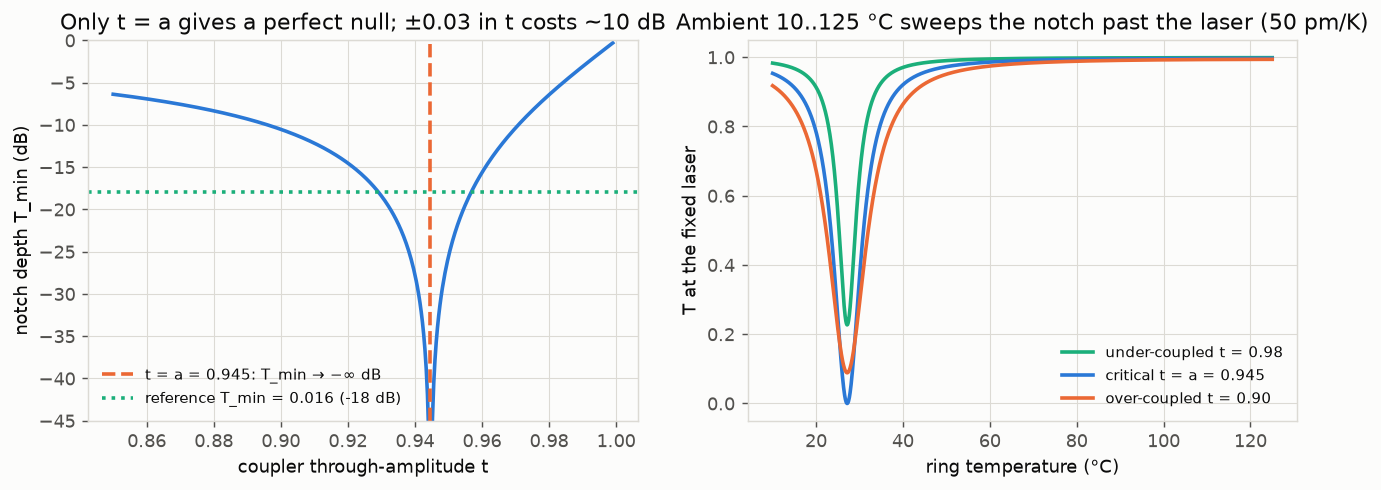

In [4]:
a_d = retention(REF.loss_db_cm_doped)
ts = np.linspace(0.85, 0.999, 400)
tmin = ((ts - a_d) / (1 - ts * a_d)) ** 2
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(ts, 10 * np.log10(tmin), color=SERIES[0])
ax[0].axvline(a_d, color=SERIES[1], ls="--", label=f"t = a = {a_d:.3f}: T_min → −∞ dB")
ax[0].axhline(10 * np.log10(REF.t_min), color=SERIES[2], ls=":", label=f"reference T_min = {REF.t_min} ({10*np.log10(REF.t_min):.0f} dB)")
ax[0].set(xlabel="coupler through-amplitude t", ylabel="notch depth T_min (dB)", ylim=(-45, 0), title="Only t = a gives a perfect null; ±0.03 in t costs ~10 dB")
ax[0].legend(fontsize=8.5)
temps = np.linspace(REF.ambient_min_c, REF.ambient_max_c, 2000)
for tt, lab, c in [(0.98, "under-coupled t = 0.98", SERIES[2]), (a_d, f"critical t = a = {a_d:.3f}", SERIES[0]), (0.90, "over-coupled t = 0.90", SERIES[1])]:
    TL = np.array([ring_T(np.array([LAM_L - (tc - 25) * DLDT]), tt, a_d)[0][0] for tc in temps])
    ax[1].plot(temps, TL, color=c, label=lab)
ax[1].set(xlabel="ring temperature (°C)", ylabel="T at the fixed laser", title="Ambient 10..125 °C sweeps the notch past the laser (50 pm/K)")
ax[1].legend(fontsize=8.5); plt.show()

## 4. The FDTD ring from Part B (if `out/B_results.json` exists)
Loads the Meep numbers and the flux spectrum written by `run.py` and overlays the closed form with the t and a inferred from the FDTD notch.

2-D FDTD: n_eff 3.339, n_g 3.594, gap 100 nm, FSR 11.73 nm, central dip 1313.09 nm: T_min 0.656, Q 4201 (Harminv 4391)
inferred from the notch: t = 0.9923, a = 0.9293  (loss calibration gave a = 0.9446); critical coupling would need a gap of ~42 nm in 2-D


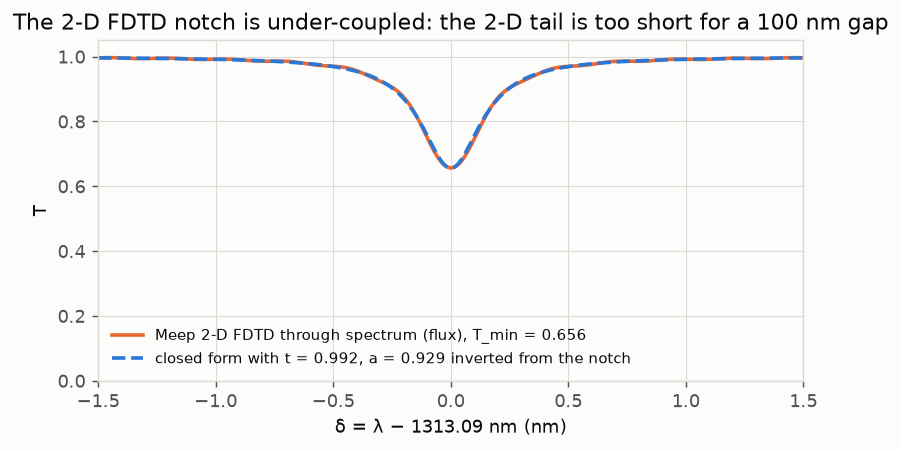

In [5]:
p = OUT / "B_results.json"
if p.exists():
    B = json.load(open(p))
    print(f"2-D FDTD: n_eff {B['neff_2d']:.3f}, n_g {B['ng_2d']:.3f}, gap {B['gap_um']*1e3:.0f} nm, FSR {B['fsr_nm_fdtd_flux']:.2f} nm, "
          f"central dip {B['central_dip_nm']:.2f} nm: T_min {B['central_dip_Tmin']:.3f}, Q {B['central_dip_Q_flux']:.0f} (Harminv {B['central_dip_Q_harminv']:.0f})")
    print(f"inferred from the notch: t = {B['t_from_fdtd']:.4f}, a = {B['a_from_fdtd']:.4f}  (loss calibration gave a = {B['a_from_calibrated_loss']:.4f}); "
          f"critical coupling would need a gap of ~{B['gap_for_critical_coupling_um']*1e3:.0f} nm in 2-D")
    d = np.linspace(-1.5, 1.5, 1201)
    # phase index nudged so that a resonance of the closed form sits exactly at the FDTD dip (same trick as for the 1310 nm ring)
    # ring_T's dispersion is written about LAM0 = 1310 nm: n(λ) = neff − (λ − λ0)(n_g − neff)/λ0, so at λ_c
    # n(λ_c) = neff·λ_c/λ0 − Δ·n_g/λ0 with Δ = λ_c − λ0; require n(λ_c)·L/λ_c = m (integer) and solve for neff.
    L2 = B['L_ring_geom_um']; lam_c = B['central_dip_nm']; ng2 = B['ng_2d']; dlt = (lam_c - LAM0) * 1e-3
    m2 = round(B['neff_2d'] * L2 / (lam_c * 1e-3))
    neff_c = (m2 * lam_c * 1e-3 / L2 + dlt * ng2 / (LAM0 * 1e-3)) * (LAM0 * 1e-3) / (lam_c * 1e-3)
    Tt, _ = ring_T(lam_c + d, B['t_from_fdtd'], B['a_from_fdtd'], ng=B['ng_2d'], neff=neff_c, L_um=L2)
    lam_fd = np.array(B['spectrum_lambda_nm']); T_fd = np.array(B['spectrum_T'])      # the B4 flux spectrum saved by ring_meep.py
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(lam_fd - lam_c, T_fd, color=SERIES[1], label=f"Meep 2-D FDTD through spectrum (flux), T_min = {B['central_dip_Tmin']:.3f}")
    ax.plot(d, Tt, "--", color=SERIES[0], label=f"closed form with t = {B['t_from_fdtd']:.3f}, a = {B['a_from_fdtd']:.3f} inverted from the notch")
    ax.set(xlabel=f"δ = λ − {B['central_dip_nm']:.2f} nm (nm)", ylabel="T", xlim=(-1.5, 1.5), ylim=(0, 1.05),
           title="The 2-D FDTD notch is under-coupled: the 2-D tail is too short for a 100 nm gap")
    ax.legend(fontsize=8.5); plt.show()
else:
    print("run ../../.meep/bin/python ring_meep.py (or run.py) first")

## Things to try
* Set **t = 0.945, a = 0.9986** (passive ring, same coupler): the notch almost vanishes — the doping loss is what makes the modulator notch deep.
* Set **a = 0.9986, t = 0.9986**: a passive ring at its own critical coupling has Q ≈ 1.4×10⁵ and a 9 pm FWHM; 0.1 K (5 pm) would then move you off resonance completely.
* Slide **temperature** from 25 to 231 °C: the laser sees one full FSR (10.3 nm / 50 pm/K = 206 K).
* Change **n_g** from 4.2 to 3.6 (the 2-D FDTD value): the FSR grows to 12 nm while the notch depth does not change — FSR depends on n_g, the depth only on t and a.